<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales
# Trabajo Práctico Nº5 : Estimación espectral mediante el método de Welch
#### Patricia González Todd



El objetivo de este trabajo es analizar la densidad espectral de potencia (PSD) de distintos tipos de señales reales mediante el método de Welch, que consiste en promediar periodogramas obtenidos sobre segmentos solapados de la señal, reduciendo la varianza de la estimación a costa de cierta resolución espectral. Para cada señal se estudia el efecto del parámetro nperseg sobre la estimación, evaluando el compromiso entre resolución espectral y varianza.

Las señales analizadas son:

ECG (electrocardiograma): registrado durante una prueba de esfuerzo, muestreado a 1000 Hz.
PPG (pletismografía): registro en reposo, muestreado a 400 Hz.
Audio: tres registros de voz pronunciando una frase y dos registros de silbido de una melodía conocida.

Para estimar el ancho de banda de cada señal se utiliza el criterio de energía acumulada: se define el ancho de banda como la frecuencia a partir de la cual la PSD acumulada normalizada alcanza el 99% de la energía total.


## ECG:
En primer lugar analizaremos la señal (sin ruido) de un electrocardiograma, obtenido durante una prueba de esfuerzo, muestreado a 1000 Hz. 

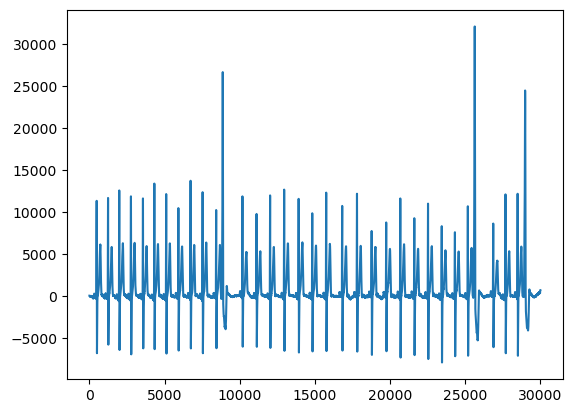

In [67]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt  
import scipy.io as sio

#%%###############
## ECG sin ruido
##################
ecg_one_lead = np.load('ecg_sin_ruido.npy')
fs_ecg = 1000
ecg_one_lead = np.load('ecg_sin_ruido.npy')

plt.figure()
plt.plot(ecg_one_lead)

N_ecg = len(ecg_one_lead)

ecg = np.reshape(ecg_one_lead , (1, N_ecg))

La estimación de la PSD se realizó mediante el método de Welch con ventana Hamming y solapamiento del 50%, variando el parámetro nperseg entre 250 y 2000 muestras, para este gráfico se escaló la PSD por su máximo con el único fin de subir normalizar lo más posible los máximos además de mejorar la visualización entre los espectros. Es importante resaltar que al estar escalada cada una por su maximo se representará cada señal en un nivel distinto, se debe entender que esto realiza por facilidad visual pero en realizad todas pertenecen a un mismo nivel con sus diferencias en nivel de detalle.

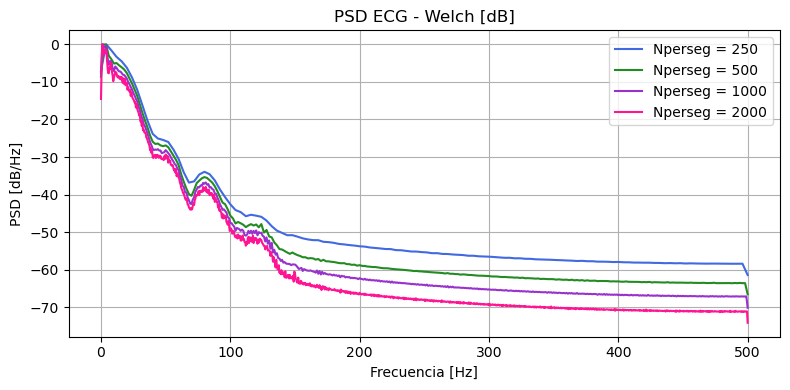

In [68]:
#Estimación:
nperseg_vec = [250, 500, 1000, 2000]
resultados = []
colores = ['royalblue', 'forestgreen', 'darkorchid', 'deeppink']

fig_db, ax_db = plt.subplots(figsize=(8, 4))
for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    f, PSD = sig.welch(ecg_one_lead - np.mean(ecg_one_lead),fs=fs_ecg,window='hamming',nperseg=div,noverlap=div//2)
    PSD_norm = PSD / np.max(PSD)
    PSD_db = 10*np.log10(PSD_norm + 1e-12)
    
     # Métricas
    delta_f = fs_ecg / div
    varianza = np.var(PSD)
    energia_norm = np.cumsum(PSD) / np.sum(PSD)
    indice_bw = np.where(energia_norm >= 0.99)[0][0]
    bw_95 = f[indice_bw]
    resultados.append([div, delta_f, varianza, bw_95])

    # --- Gráfico dB ---
    ax_db.plot(f, PSD_db, color=color, label=f'Nperseg = {div}')

# --- Config gráfico dB ---
ax_db.set_title('PSD ECG - Welch [dB]')
ax_db.set_xlabel('Frecuencia [Hz]')
ax_db.set_ylabel('PSD [dB/Hz]')
ax_db.grid(True)
ax_db.legend()
fig_db.tight_layout()

plt.show()

Desde el gráfico ya se puede evidenciarque si bien un Nperseg alto permite curvas más marcadas y detalladas, al mismo tiempo se manifiesta mayor irregularidad en el recorrido de esta, este es el famoso compromiso entre resolución y varianza, donde la mejora de una encusia a la otra, como se puede ver en el Nperseg bajo, que nos muestra menos detalles con curvas muchisimo más regulares. 

Toda esta comparativa la podemos ver perfectamente en la tabla presentada:

In [69]:
# =========================
# IMPRIMIR TABLA
# =========================
print("\n TABLA COMPARATIVA CCG")
print(f"{'Nperseg':<10} | {'Δf [Hz]':<10} | {'Varianza':<15} | {'BW 95% [Hz]':<15}")
print("-"*65)
for r in resultados:
    print(f"{r[0]:<10} | "f"{r[1]:<10.4f} | "f"{r[2]:<15.6e} | "f"{r[3]:<15.2f}")


 TABLA COMPARATIVA CCG
Nperseg    | Δf [Hz]    | Varianza        | BW 95% [Hz]    
-----------------------------------------------------------------
250        | 4.0000     | 2.806350e+09    | 32.00          
500        | 2.0000     | 4.479053e+09    | 32.00          
1000       | 1.0000     | 6.581683e+09    | 31.00          
2000       | 0.5000     | 7.812022e+09    | 30.50          


Llamamos $BW$ al ancho de banda, el cual definimos como la sección que contiene al 99% de la potencia de la señal, calculando a esta como una integral izquierda (suma acumulada) y se decta el primer índice donde se alcanza esa fracciónde de energía. 

Al representarse la PSD en escala logarítmica no se logra apreciar esta disminución marcada de energía a partir de este límite establecido de BW, por tanto se graficará en escala lineal a modo ilustrativo del ancho de banda:

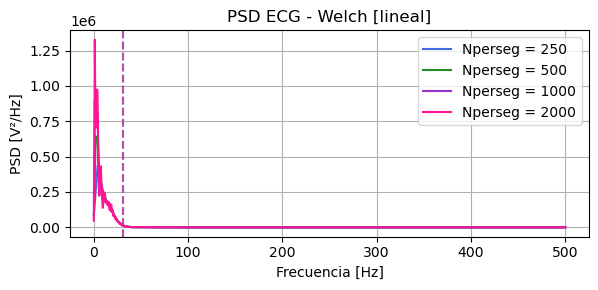

In [70]:
fig_lin, ax_lin = plt.subplots(figsize=(6, 3))
i = 0
for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    f, PSD = sig.welch(ecg_one_lead - np.mean(ecg_one_lead),fs=fs_ecg,window='hamming',nperseg=div,noverlap=div//2)
    
    # --- Gráfico lineal ---
    ax_lin.plot(f, PSD, color=color, label=f'Nperseg = {div}')
    ax_lin.axvline(x=bw_95, color=color, linestyle='--', alpha=0.4)

# --- Config gráfico lineal ---
ax_lin.set_title('PSD ECG - Welch [lineal]')
ax_lin.set_xlabel('Frecuencia [Hz]')
ax_lin.set_ylabel('PSD [V²/Hz]')
ax_lin.grid(True)
ax_lin.legend()
fig_lin.tight_layout()

plt.show()

print("\n")


En el resto de las señales podremos ver el mismo compormiso entre resolución y varianza en base el Nperseg

## PPG:
Ahora podremos replicar la demostración para una plestismografía, otro tipo de muestra biomédica aportada para el análisis.

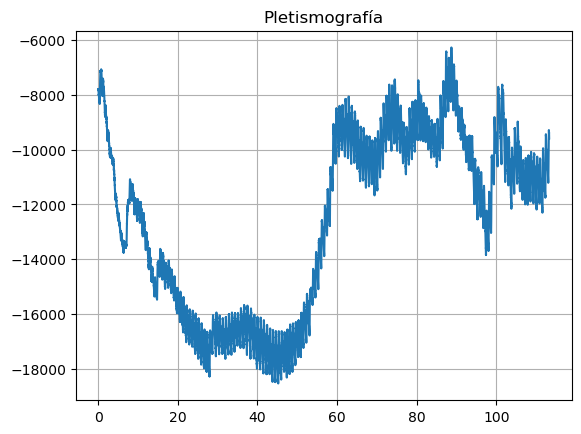

In [72]:
#%%#######################
# Pletismografía (PPG.csv)
##########################

ppg = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)
if ppg.ndim > 1:
    ppg = ppg[:, 0]           # Tomar solo la primera columna

fs_ppg = 400  # Hz

N_ppg = len(ppg)
T_ppg = N_ppg / fs_ppg
t_ppg = np.arange(N_ppg) / fs_ppg

plt.figure()
plt.plot(t_ppg, ppg)
plt.title("Pletismografía")
plt.grid()
plt.show()


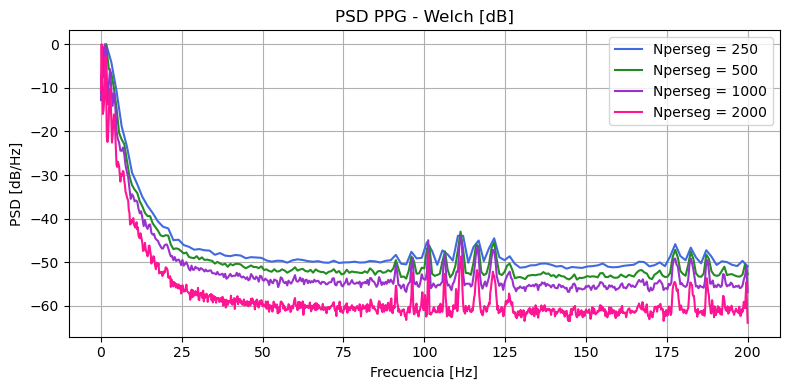

In [85]:
#Estimación:
nperseg_vec = [250, 500, 1000, 2000]
resultados = []
colores = ['royalblue', 'forestgreen', 'darkorchid', 'deeppink']

fig_db, ax_db = plt.subplots(figsize=(8, 4))

for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    f, PSD = sig.welch( ppg - np.mean(ppg), fs=fs_ppg, window='hamming', nperseg=div, noverlap=div//2)
    PSD_norm = PSD / np.max(PSD)
    PSD_db = 10*np.log10(PSD_norm + 1e-12)
    
    # Métricas
    delta_f = fs_ppg / div
    varianza = np.var(PSD)
    energia_norm = np.cumsum(PSD) / np.sum(PSD)
    indice_bw = np.where(energia_norm >= 0.99)[0][0]
    bw_95 = f[indice_bw]
    resultados.append([div, delta_f, varianza, bw_95])

    # --- Gráfico dB ---
    ax_db.plot(f, PSD_db, color=color, label=f'Nperseg = {div}')

# --- Config gráfico dB ---
ax_db.set_title('PSD PPG - Welch [dB]')
ax_db.set_xlabel('Frecuencia [Hz]')
ax_db.set_ylabel('PSD [dB/Hz]')
ax_db.grid(True)
ax_db.legend()
fig_db.tight_layout()

plt.show()

In [89]:
# =========================
# IMPRIMIR TABLA
# =========================
print("\nTABLA COMPARATIVA PPG")
print(f"{'Nperseg':<10} | {'Δf [Hz]':<10} | {'Varianza':<15} | {'BW 95% [Hz]':<15}")
print("-"*65)
for r in resultados:
    print(f"{r[0]:<10} | "f"{r[1]:<10.4f} | "f"{r[2]:<15.6e} | "f"{r[3]:<15.2f}")
print("\n")


TABLA COMPARATIVA PPG
Nperseg    | Δf [Hz]    | Varianza        | BW 95% [Hz]    
-----------------------------------------------------------------
250        | 1.6000     | 6.194972e+07    | 6.40           
500        | 0.8000     | 1.422824e+08    | 5.60           
1000       | 0.4000     | 2.428590e+08    | 5.20           
2000       | 0.2000     | 1.148175e+09    | 4.60           




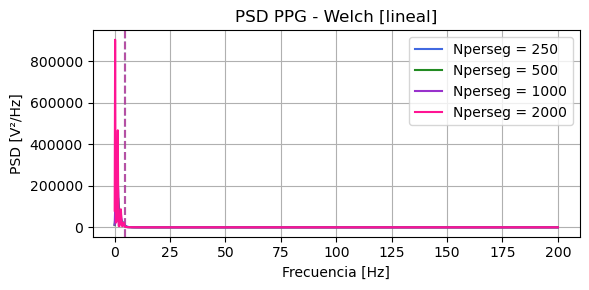

In [90]:
fig_lin, ax_lin = plt.subplots(figsize=(6, 3))

for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    f, PSD = sig.welch( ppg - np.mean(ppg), fs=fs_ppg, window='hamming', nperseg=div, noverlap=div//2)

    # --- Gráfico lineal ---
    ax_lin.plot(f, PSD, color=color, label=f'Nperseg = {div}')
    ax_lin.axvline(x=bw_95, color=color, linestyle='--', alpha=0.4)

# --- Config gráfico lineal ---
ax_lin.set_title('PSD PPG - Welch [lineal]')
ax_lin.set_xlabel('Frecuencia [Hz]')
ax_lin.set_ylabel('PSD [V²/Hz]')
ax_lin.grid(True)
ax_lin.legend()
fig_lin.tight_layout()

plt.show()

Podemos notar que en otr tipo de señal biomédica, esta vez contenida en una ventana más pequeña y con un ancho de banda mucho menor, se replica el mismo comportamiento, donde a menor $Δf$ mayor varianza, indicando en el momento de querer mejorar los detalles o resolución siempre me voy a encontrar ensuciando en alguna proporción la señal.

# Señales de audio:
Se realizará el mismo estilo de demostración para 3 señales distintas de audio, en ellas podemos notar distintos comportamientos en frecuencia, la mayoría mucho más parecidas a comportamientos pasabanda, de modo que se evaluará un inicio y un findel ancho de banda según el bloque donde se concentre el 99% de la potencia d ela señal. Se buscará nuevamente ver el comportamiento típico de la estimación de Welch, donde el compromiso varianza-resolución nos debería decir que a menor resolución mayor varianza.

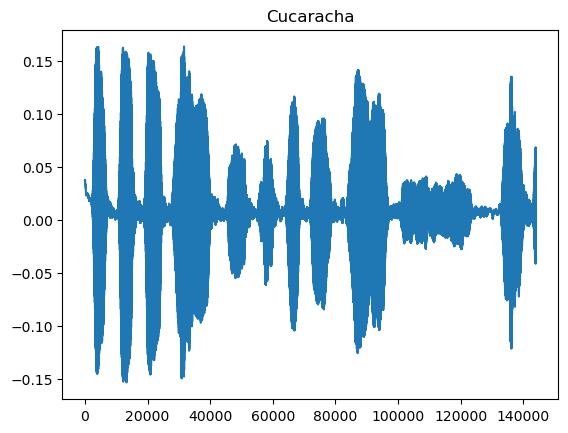

In [132]:
#%%###############
## AUDIO CUCARACHA
##################
fs_cucaracha, cuca_wav = sio.wavfile.read('la cucaracha.wav')

plt.figure()
plt.plot(cuca_wav)
plt.title("Cucaracha")
plt.show()


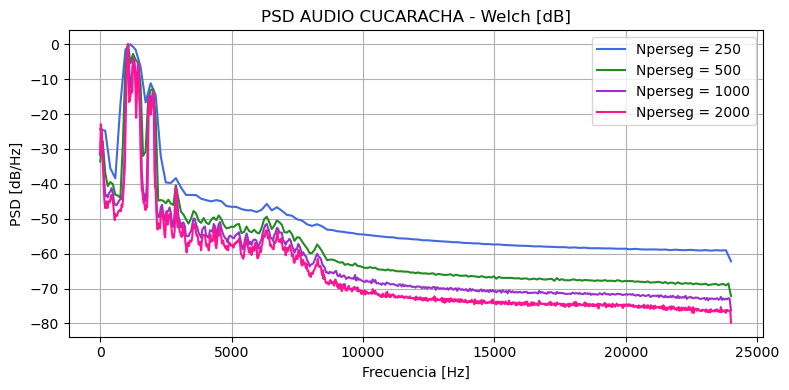

In [197]:
nperseg_vec = [250, 500, 1000, 2000]
resultados = []
colores = ['royalblue', 'forestgreen', 'darkorchid', 'deeppink']

fig_db, ax_db = plt.subplots(figsize=(8, 4))

for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    f, PSD = sig.welch( cuca_wav - np.mean(cuca_wav), fs=fs_cucaracha, window='hamming', nperseg=div, noverlap=div//2)

    # Métricas
    delta_f = fs_cucaracha / div
    varianza = np.var(PSD)
    energia_norm = np.cumsum(PSD) / np.sum(PSD)
    # --- BW inferior  ---
    indice_bw_low = np.where(energia_norm >= 0.05)[0][0]  # complemento del 95%
    bw_low = f[indice_bw_low]
     # --- BW superior  ---
    indice_bw_high = np.where(energia_norm >= 0.99)[0][0]
    bw_high = f[indice_bw_high]
    resultados.append([div, delta_f, varianza, bw_low, bw_high])

    PSD_norm = PSD / np.max(PSD)
    PSD_db = 10*np.log10(PSD_norm + 1e-12)
    
    # --- Gráfico dB ---
    ax_db.plot(f, PSD_db, color=color, label=f'Nperseg = {div}')

# --- Config gráfico dB ---
ax_db.set_title('PSD AUDIO CUCARACHA - Welch [dB]')
ax_db.set_xlabel('Frecuencia [Hz]')
ax_db.set_ylabel('PSD [dB/Hz]')
ax_db.grid(True)
ax_db.legend()
fig_db.tight_layout()

plt.show()

In [198]:
# =========================
# IMPRIMIR TABLA
# =========================
print("\nTABLA COMPARATIVA CUCARACHA")
print(f"{'Nperseg':<10} | {'Δf [Hz]':<10} | {'Varianza':<15} | {'BW inferior [Hz]':<15} | {'BW superior [Hz]':<15}")
print("-"*65)
for r in resultados:
    print(f"{r[0]:<10} | "f"{r[1]:<10.4f} | "f"{r[2]:<15.6e} | "f"{r[3]:<15.2f} | "f"{r[4]:<15.2f}")
print("\n")


TABLA COMPARATIVA CUCARACHA
Nperseg    | Δf [Hz]    | Varianza        | BW inferior [Hz] | BW superior [Hz]
-----------------------------------------------------------------
250        | 192.0000   | 1.814860e-13    | 960.00          | 2112.00        
500        | 96.0000    | 2.683164e-13    | 960.00          | 2016.00        
1000       | 48.0000    | 4.237094e-13    | 1008.00         | 2016.00        
2000       | 24.0000    | 6.238879e-13    | 1032.00         | 2016.00        




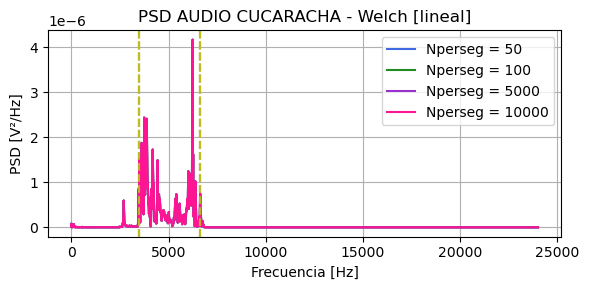



Tamaño del ancho de banda CUCHARACHA: 3153.600000000001


In [213]:

fig_lin, ax_lin = plt.subplots(figsize=(6, 3))

for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    # --- Gráfico lineal ---
    ax_lin.plot(f, PSD, color=color, label=f'Nperseg = {div}')
    ax_lin.axvline(x=bw_low,  color= "C8", linestyle='--',  alpha=0.9)  # límite inferior
    ax_lin.axvline(x=bw_high, color= "C8", linestyle='--', alpha=0.9)  # límite superior
    
# --- Config gráfico lineal ---
ax_lin.set_title('PSD AUDIO CUCARACHA - Welch [lineal]')
ax_lin.set_xlabel('Frecuencia [Hz]')
ax_lin.set_ylabel('PSD [V²/Hz]')
ax_lin.grid(True)
ax_lin.legend()
fig_lin.tight_layout()

plt.show()

print("\n")
print(f"Tamaño del ancho de banda CUCHARACHA: {bw_high - bw_low}")

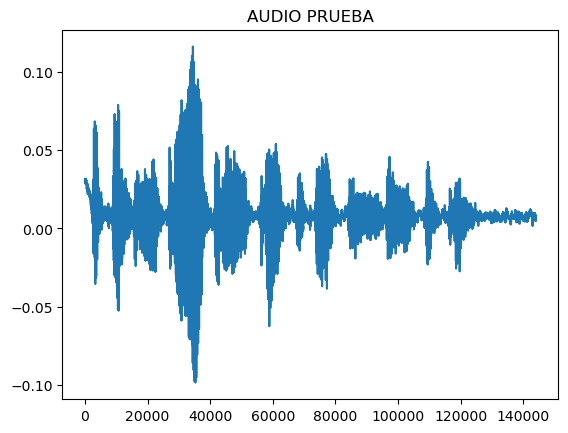

In [201]:
#%%###############
## AUDIO PRUEBA
##################
fs_prueba_au, prueba_wav = sio.wavfile.read('prueba psd.wav')
plt.figure()
plt.plot(prueba_wav)
plt.title("AUDIO PRUEBA")
plt.show()

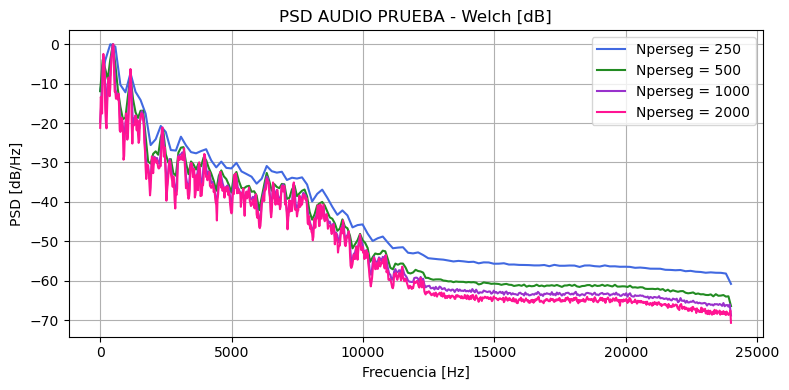

In [202]:
nperseg_vec = [250, 500, 1000, 2000]
resultados = []
colores = ['royalblue', 'forestgreen', 'darkorchid', 'deeppink']

fig_db, ax_db = plt.subplots(figsize=(8, 4))

for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    f, PSD = sig.welch( prueba_wav - np.mean(prueba_wav), fs=fs_prueba_au, window='hamming', nperseg=div, noverlap=div//2)

    # Métricas
    delta_f = fs_prueba_au / div
    varianza = np.var(PSD)
    energia_norm = np.cumsum(PSD) / np.sum(PSD)
    # --- BW inferior  ---
    indice_bw_low = np.where(energia_norm >= 0.05)[0][0]  # complemento del 95%
    bw_low = f[indice_bw_low]
     # --- BW superior  ---
    indice_bw_high = np.where(energia_norm >= 0.99)[0][0]
    bw_high = f[indice_bw_high]
    resultados.append([div, delta_f, varianza, bw_low, bw_high])

    PSD_norm = PSD / np.max(PSD)
    PSD_db = 10*np.log10(PSD_norm + 1e-12)
    
    # --- Gráfico dB ---
    ax_db.plot(f, PSD_db, color=color, label=f'Nperseg = {div}')

# --- Config gráfico dB ---
ax_db.set_title('PSD AUDIO PRUEBA - Welch [dB]')
ax_db.set_xlabel('Frecuencia [Hz]')
ax_db.set_ylabel('PSD [dB/Hz]')
ax_db.grid(True)
ax_db.legend()
fig_db.tight_layout()

plt.show()


In [203]:
# =========================
# IMPRIMIR TABLA
# =========================
print("\nTABLA COMPARATIVA AUDIO PRUEBA")
print(f"{'Nperseg':<10} | {'Δf [Hz]':<10} | {'Varianza':<15} | {'BW inferior [Hz]':<15} | {'BW superior [Hz]':<15}")
print("-"*65)
for r in resultados:
    print(f"{r[0]:<10} | "f"{r[1]:<10.4f} | "f"{r[2]:<15.6e} | "f"{r[3]:<15.2f} | "f"{r[4]:<15.2f}")
print("\n")


TABLA COMPARATIVA AUDIO PRUEBA
Nperseg    | Δf [Hz]    | Varianza        | BW inferior [Hz] | BW superior [Hz]
-----------------------------------------------------------------
250        | 192.0000   | 1.107431e-15    | 192.00          | 2880.00        
500        | 96.0000    | 1.953856e-15    | 96.00           | 2592.00        
1000       | 48.0000    | 2.618031e-15    | 96.00           | 2640.00        
2000       | 24.0000    | 3.362819e-15    | 120.00          | 2616.00        




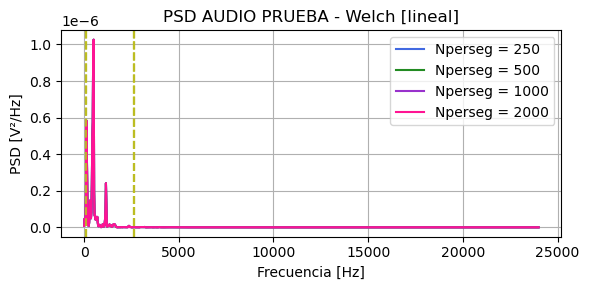



Tamaño del ancho de banda AUDIO PRUEBA: 2496.0


In [204]:

fig_lin, ax_lin = plt.subplots(figsize=(6, 3))

for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    # --- Gráfico lineal ---
    ax_lin.plot(f, PSD, color=color, label=f'Nperseg = {div}')
    ax_lin.axvline(x=bw_low,  color= "C8", linestyle='--',  alpha=0.9)  # límite inferior
    ax_lin.axvline(x=bw_high, color= "C8", linestyle='--', alpha=0.9)  # límite superior
    
# --- Config gráfico lineal ---
ax_lin.set_title('PSD AUDIO PRUEBA - Welch [lineal]')
ax_lin.set_xlabel('Frecuencia [Hz]')
ax_lin.set_ylabel('PSD [V²/Hz]')
ax_lin.grid(True)
ax_lin.legend()
fig_lin.tight_layout()

plt.show()

print("\n")
print(f"Tamaño del ancho de banda AUDIO PRUEBA: {bw_high - bw_low}")

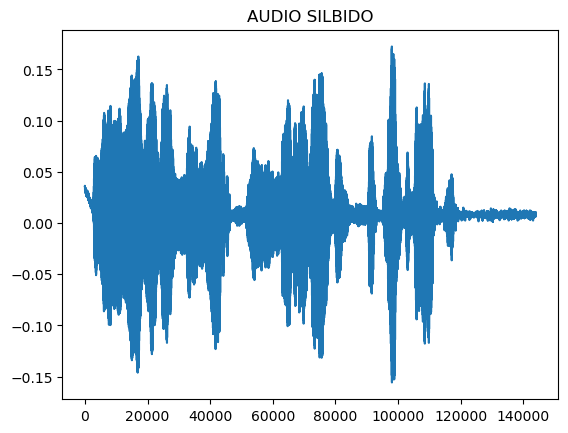

In [205]:
#%%###############
## AUDIO SILBIDO
##################
fs_silba, silba_wav = sio.wavfile.read('silbido.wav')
plt.figure()
plt.plot(silba_wav)
plt.title("AUDIO SILBIDO")
plt.show()

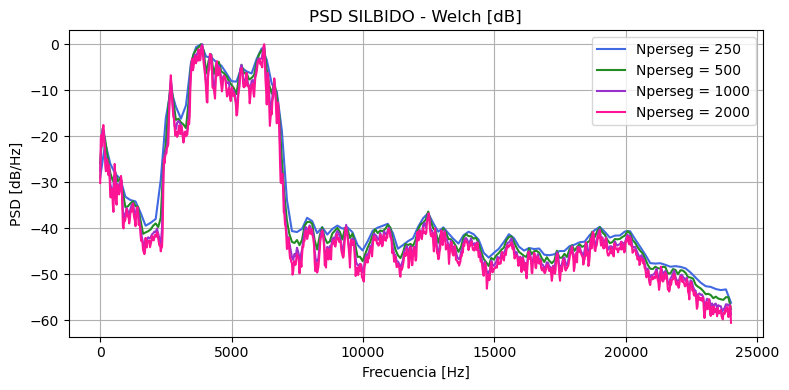

In [207]:
nperseg_vec = [250, 500, 1000, 2000]
resultados = []
colores = ['royalblue', 'forestgreen', 'darkorchid', 'deeppink']

fig_db, ax_db = plt.subplots(figsize=(8, 4))

for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    f, PSD = sig.welch( silba_wav - np.mean(silba_wav), fs=fs_silba, window='hamming', nperseg=div, noverlap=div//2)
    PSD_norm = PSD / np.max(PSD)
    PSD_db = 10*np.log10(PSD_norm + 1e-12)

    # Métricas
    delta_f = fs_silba / div
    varianza = np.var(PSD)
    energia_norm = np.cumsum(PSD) / np.sum(PSD)
    # --- BW inferior  ---
    indice_bw_low = np.where(energia_norm >= 0.05)[0][0]  # complemento del 95%
    bw_low = f[indice_bw_low]
     # --- BW superior  ---
    indice_bw_high = np.where(energia_norm >= 0.99)[0][0]
    bw_high = f[indice_bw_high]
    
    resultados.append([div, delta_f, varianza, bw_low, bw_high])

    # --- Gráfico dB ---
    ax_db.plot(f, PSD_db, color=color, label=f'Nperseg = {div}')

# --- Config gráfico dB ---
ax_db.set_title('PSD SILBIDO - Welch [dB]')
ax_db.set_xlabel('Frecuencia [Hz]')
ax_db.set_ylabel('PSD [dB/Hz]')
ax_db.grid(True)
ax_db.legend()
fig_db.tight_layout()

plt.show()


In [208]:
# =========================
# IMPRIMIR TABLA
# =========================
print("\nTABLA COMPARATIVA SILBIDO")
print(f"{'Nperseg':<10} | {'Δf [Hz]':<10} | {'Varianza':<15} | {'BW inferior [Hz]':<15} | {'BW superior [Hz]':<15}")
print("-"*65)
for r in resultados:
    print(f"{r[0]:<10} | "f"{r[1]:<10.4f} | "f"{r[2]:<15.6e} | "f"{r[3]:<15.2f} | "f"{r[4]:<15.2f}")
print("\n")


TABLA COMPARATIVA SILBIDO
Nperseg    | Δf [Hz]    | Varianza        | BW inferior [Hz] | BW superior [Hz]
-----------------------------------------------------------------
250        | 192.0000   | 3.193566e-14    | 3456.00         | 6720.00        
500        | 96.0000    | 3.624230e-14    | 3456.00         | 6624.00        
1000       | 48.0000    | 4.078740e-14    | 3504.00         | 6672.00        
2000       | 24.0000    | 4.474478e-14    | 3480.00         | 6648.00        




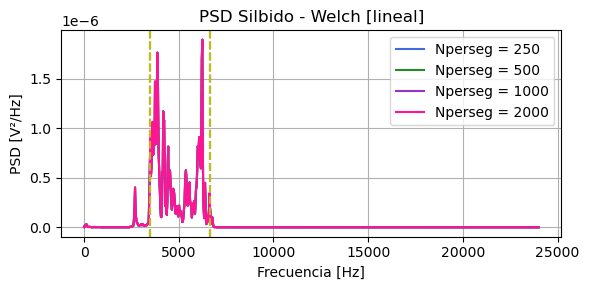



Tamaño del ancho de banda SILBIDO: 3168.0


In [210]:

fig_lin, ax_lin = plt.subplots(figsize=(6, 3))

for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    # --- Gráfico lineal ---
    ax_lin.plot(f, PSD, color=color, label=f'Nperseg = {div}')
    ax_lin.axvline(x=bw_low,  color= "C8", linestyle='--',  alpha=0.9)  # límite inferior
    ax_lin.axvline(x=bw_high, color= "C8", linestyle='--', alpha=0.9)  # límite superior
    
# --- Config gráfico lineal ---
ax_lin.set_title('PSD Silbido - Welch [lineal]')
ax_lin.set_xlabel('Frecuencia [Hz]')
ax_lin.set_ylabel('PSD [V²/Hz]')
ax_lin.grid(True)
ax_lin.legend()
fig_lin.tight_layout()

plt.show()

print("\n")
print(f"Tamaño del ancho de banda SILBIDO: {bw_high - bw_low}")
print("\n")



Luego de visualizar las estimaciones de 3 señales distintas de audio se puede resaltar la gran diferencia entre la  relación resolucion-varianza. En este tipo de señales se resalta un valor de varianza muy chico en comparación a la resolución espectral, para iguales valores de Nperseg a los usados para señales biomédicas, tenemos varianzas insiignificantes para resoluciones muy altas. Por esta razón repetiremos parte de la experiencia  ppara una de las señales de audio para variados valores de Nperseg para analizar su comportamineto:

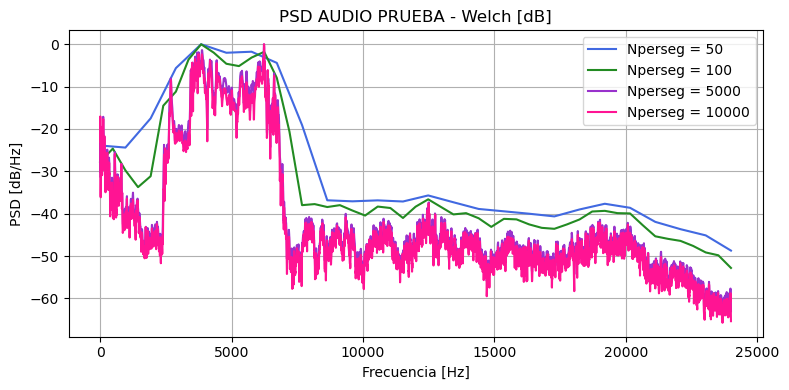

In [211]:
nperseg_vec = [50,100, 5000, 10000]
resultados = []
colores = ['royalblue', 'forestgreen', 'darkorchid', 'deeppink']

fig_db, ax_db = plt.subplots(figsize=(8, 4))

for i, div in enumerate(nperseg_vec):
    color = colores[i]
    
    f, PSD = sig.welch( silba_wav - np.mean(silba_wav), fs=fs_silba, window='hamming', nperseg=div, noverlap=div//2)
    PSD_norm = PSD / np.max(PSD)
    PSD_db = 10*np.log10(PSD_norm + 1e-12)

    # Métricas
    delta_f = fs_silba / div
    varianza = np.var(PSD)
    energia_norm = np.cumsum(PSD) / np.sum(PSD)
    # --- BW inferior  ---
    indice_bw_low = np.where(energia_norm >= 0.05)[0][0]  # complemento del 95%
    bw_low = f[indice_bw_low]
     # --- BW superior  ---
    indice_bw_high = np.where(energia_norm >= 0.99)[0][0]
    bw_high = f[indice_bw_high]
    
    resultados.append([div, delta_f, varianza, bw_low, bw_high])

    # --- Gráfico dB ---
    ax_db.plot(f, PSD_db, color=color, label=f'Nperseg = {div}')

# --- Config gráfico dB ---
ax_db.set_title('PSD AUDIO PRUEBA - Welch [dB]')
ax_db.set_xlabel('Frecuencia [Hz]')
ax_db.set_ylabel('PSD [dB/Hz]')
ax_db.grid(True)
ax_db.legend()
fig_db.tight_layout()

plt.show()

In [212]:
# =========================
# IMPRIMIR TABLA
# =========================
print("\nNueva Tabla comparativa cucaracha")
print(f"{'Nperseg':<10} | {'Δf [Hz]':<10} | {'Varianza':<15} | {'BW inferior [Hz]':<15} | {'BW superior [Hz]':<15}")
print("-"*65)
for r in resultados:
    print(f"{r[0]:<10} | "f"{r[1]:<10.4f} | "f"{r[2]:<15.6e} | "f"{r[3]:<15.2f} | "f"{r[4]:<15.2f}")
print("\n")


Nueva Tabla comparativa cucaracha
Nperseg    | Δf [Hz]    | Varianza        | BW inferior [Hz] | BW superior [Hz]
-----------------------------------------------------------------
50         | 960.0000   | 1.882648e-14    | 2880.00         | 6720.00        
100        | 480.0000   | 2.489750e-14    | 3360.00         | 6720.00        
5000       | 9.6000     | 4.882452e-14    | 3494.40         | 6652.80        
10000      | 4.8000     | 5.935254e-14    | 3480.00         | 6633.60        




Nuevamente se puede evidenciar un comportamiento marcadamente distinto con señales biomédicas, se puede ver que aunque realicemos grandes cambios en la longitud de los segmentos, la varianza es notablemnete estable aunque la resolución espectral empeore avismalmente, infiriendo el mismo comportamiento para las otras señales de audio estudiadas.

## Conclusión:
Las señales biomédicas (ECG, PPG) mostraron BW reducidos y varianza sensible a nperseg, mientras que las señales de audio presentaron BW mucho más amplios y varianza estable frente a cambios en la segmentación.